# HW1-课后练习

<span style="color:red; font-weight:bold;">此次作业是课后练习，供大家熟练课堂上讲授的知识点，不计入任何分数。</span>

<span style="color:red; font-weight:bold;">请将作业命名为 HW1-课后练习+姓名+学号.ipynb, 例如 HW1-课后练习+张三+1000000000.ipynb</span>


### 第零部分：阅读代码，理解代码的功能，先写出预想的结果。运行并检验结果是否如预期。如果不如预期，请分析理解其中的原因

In [1]:
i = 1.1
j = 11

print(j//i)
print('a' + 1)

9.0


TypeError: can only concatenate str (not "int") to str

In [2]:
def rec_sum(n):
    if n == 0:
        return 0
    else:
        return n + rec_sum(n-1)
    
rec_sum(4)  # 如果输入参数为-4，观察运行结果如何？
rec_sum(-4)

RecursionError: maximum recursion depth exceeded

In [3]:
s = '[2,6,1,3,7,2,7]'
nums = s[1:-1].split(",")
result = [num for num in nums if nums.count(num) == 1]

print(result)

['6', '1', '3']


In [4]:
num = 210
result = []

for factor in range(2, int(num ** 0.5) + 1):
    while num % factor == 0:
        result.append(chr(factor + 48))
        num = num // factor
    factor += 1

print(result)
print("*".join(result))

['2', '3', '5', '7']
2*3*5*7


In [5]:
data = [1,2,3,4]
for x in data:
    if x % 2 == 0:
        data.remove(x)
print(data)

[1, 3]


In [6]:
matrix = [[0]*3]*3  # 理解列表乘法的本质：引用复制  
matrix[0][1] = 1  
print(matrix)

[[0, 1, 0], [0, 1, 0], [0, 1, 0]]


## 一、Python的基础数据类型与表达式

### 1. 类型、分支流程与输入输出
```
实现一个单汇率货币转换器，输入为美元，输出为人民币。
汇率表：
1美元 = 7.1985人民币
```

In [7]:
USD = float(input("请输入金额："))
RMB = 7.1985 * USD

print("人民币金额：", RMB)

人民币金额： 719.85


### 2. 条件表达式，分支流程
```
实现一个多汇率货币转换器，输入为美元(USD)，欧元(EUR)，日元(JPY)，输出为人民币(RMB)。
汇率表：
1美元 = 7.1985人民币
1欧元 = 7.7544人民币
1日元 = 0.0479人民币
```

In [8]:
def convert_currency(TYPE, RMB):
    if TYPE == "USD":
        return 7.1985 * RMB
    elif TYPE == "EUR":
        return 7.7544 * RMB
    elif TYPE == "JPY":
        return 0.0479 * RMB

assert convert_currency("USD", 100) == 719.85
assert convert_currency("EUR", 100) == 775.44
assert convert_currency("JPY", 100) == 4.79

### 3. 字符串处理
``` 
实现一个字符串处理函数，将输入的字符串转换为大写，然后将其中从第n个字符之后的所有' '替换为字符'_'。
```

In [9]:
def process_string(s, n):
    s = s.upper()
    return ''.join(["_" if i > n and s[i] == ' ' else s[i] for i in range(len(s))])

assert process_string('You are right, but "Genshin Impact" is a brand new open-world adventure game independently developed by miHoYo.', 20) \
    == 'YOU ARE RIGHT, BUT "GENSHIN_IMPACT"_IS_A_BRAND_NEW_OPEN-WORLD_ADVENTURE_GAME_INDEPENDENTLY_DEVELOPED_BY_MIHOYO.'


## 二、Python的序列类型与顺序计算流程

### 1. list, tuple基本操作
```
实现一个简单的计算已选课程的学分之和的函数：
1. 课程信息存储在一个列表中，列表中的每个元素是一个元组，元组的第一个元素是课程名，第二个元素是课程的学分。
2. 学生可以选择课程，选择的课程存储在一个列表中。
3. 函数可以计算已选课程的学分之和。
```


In [10]:
def calculate_total(Courses, Selected):
    sum = 0
    for name, num in Courses:
        if name in Selected:
            sum += num
    return sum

Courses = [('三宝', 2), ('音数', 2), ('地概', 2), ('高数', 4), ('线代', 3), ('棒垒', 1)]
Selected = ['三宝', '高数', '线代']
assert calculate_total(Courses, Selected) == 9

### 2. list生成、查找
```
生成一个包含1~n中所有整数的列表，扔掉其中所有被m整除的数，判断2*x+1是该列表中的第几个奇数。(我们假设2*x+1一定存在于列表中)
```

In [11]:
def find_position(n, m, x):
    return [num for num in range(1, n + 1) if num % 2 != 0 and num % m != 0].index(2*x+1)+1
    List = []
    for num in range(1, n + 1):
        if num % m != 0 and num % 2 != 0:
            List.append(num)
    try:
        return List.index(2*x+1)+1
    except ValueError:
        print('Err')

assert find_position(50, 3, 5) == 4

### 3. list, dict基本操作
```
进行英文单词的词频统计，输入一个字符串，不区分大小写，不计标点符号(我们假设只会出现'.' ','两种标点)，输出一个字典，字典的键是每个不同的英文单词，值是单词的词频。
```

In [12]:
import re
def word_frequency(s):
    s = s.replace(',', '').replace('.', '')
    split = s.split(' ')
    s_set = set(split)
    dict = {}
    for word in s_set:
        dict[word] = split.count(word)
    return dict

s = """You are right, but Genshin Impact is a brand new open world adventure game developed independently by miHoYo. The game takes place in a fantasy world called Teyvat, where individuals chosen by the gods are granted the Vision, guiding the power of elements. You will play as a mysterious character known as the Traveler, encountering companions with diverse personalities and unique abilities during your free travels. Together, you will defeat formidable enemies, reunite with lost relatives, and gradually uncover the truth behind Genshin."""
word_freq = word_frequency(s)

# 对dict的value做降序排序
word_freq = dict(sorted(word_freq.items(), key=lambda item: item[1], reverse=True))

assert 'a' in word_freq
assert word_freq['a'] == 3
assert ',' not in word_freq and '.' not in word_freq

## 三、列表生成式与迭代器

### 0.运行并观察以下几个例子，理解迭代器的基本用法

In [13]:
mytuple = ("apple", "banana", "cherry")
myit = iter(mytuple)

print(next(myit))
print(next(myit))
print(next(myit))
# 迭代器本身是一次性的
print(next(myit))

apple
banana
cherry


StopIteration: 

In [14]:
mydict = {"apple": "green", "banana": "yellow", "cherry": "red"}
for k,v in mydict.items():
    print(k,v)

apple green
banana yellow
cherry red


In [15]:
mydict = {"apple": "green", "banana": "yellow", "cherry": "red"}
myiter = iter(mydict)
while True:
    try:
        k = next(myiter)
        print(k, mydict[k])
    except StopIteration:
        break
# 思考：迭代器和容器的区别?

apple green
banana yellow
cherry red


### 1. 迭代器使用
```
在一个随机生成的包含100个10以内的数字的列表中，使用迭代器的方式输出首次出现的1之后的两个数字
```

In [16]:
import random
random.seed(42)
l=[random.randint(0,10) for _ in range(100)]
def output(l):
    idx = l.index(1)
    try:
        return l[idx + 1], l[idx + 2]
    except ValueError:
        print('Err')

assert output(l) == (0, 4)

### 2. 列表生成式

#### 2.1 使用列表生成式生成一个包含1~n中所有被m整除的数的列表。

In [17]:
n = 50
m = 3
generated_list = [i for i in range(m, n+1, m)]

assert generated_list == [3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36, 39, 42, 45, 48]

#### 2.2 使用列表生成式，从包含多个句子的文本中，找出所有单词数大于5的句子。

In [18]:
text = "This is a sample text. With several sentences. Some sentences are longer than others. We want to extract sentences with more than five words."

selected_sentences = [sentence.strip() for sentence in text.split('.') if len(sentence.split(' ')) > 5]

assert selected_sentences == ['Some sentences are longer than others', 'We want to extract sentences with more than five words']


#### 2.3 使用列表生成式，从一个包含多个人的字典列表中，生成一个包含所有年龄大于等于18岁的姓名列表。

In [19]:
people = [
    {"name": "Alice", "age": 25},
    {"name": "Bob", "age": 17},
    {"name": "Charlie", "age": 30},
    {"name": "David", "age": 16}
]
adult_names = [one['name'] for one in people if one['age'] >= 18]

assert adult_names == ['Alice', 'Charlie']


#### 2.4 使用列表生成式，生成一个包含所有(1, 1)到(3, 3)之间的整数坐标点的集合。

In [20]:
coordinates = set([(i, j) for i in range(1, 4) for j in range(1, 4)])
assert coordinates == set([(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)])

#### 2.5 使用列表生成式与zip方法，生成两个列表相同位置的元素的乘积。

In [21]:
list1 = [2, 3, 4, 5]
list2 = ['hello', 'world', 'python', 'programming']

product = [list2[idx] * list1[idx] for idx in range (4)]
assert product == ['hellohello',
                    'worldworldworld',
                    'pythonpythonpythonpython',
                    'programmingprogrammingprogrammingprogrammingprogramming']

### 第四部分：代码阅读练习：

下面是一段较长的代码，实现了文本数据清洗和关键信息提取的功能。请学习理解该段代码。

能否设计一个更加合理的关键词提取算法，以实现对得到的信息进行按关键词索引-检索的目标。把这个任务交给大语言模型，看看能否通过与AI交互合作得到一个相对有实际应用价值的方案。如果有，请把代码（包括给AI的提示）、运行测试结果贴在最后。同时给自己的作业文件名后加上一个#号字符。被课堂作业讲评引用的同学会有额外加分。

In [22]:
# 进阶示例：文本处理函数与列表生成式
import re
from typing import List, Tuple
from collections import Counter

def clean_text(text: str) -> str:
    """清理文本：移除特殊字符、转换为小写"""
    # 移除HTML标签
    text = re.sub(r'<.*?>', '', text)
    # 移除特殊字符，保留字母、数字和基本标点
    text = re.sub(r'[^\w\s.,!?-]', '', text)
    # 转换为小写
    return text.lower().strip()

def extract_emails(text: str) -> List[str]:
    """从文本中提取所有邮箱地址"""
    email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
    return re.findall(email_pattern, text)

def calculate_word_frequencies(texts: List[str], 
                             stopwords: List[str] = None) -> List[Tuple[str, int]]:
    """计算词频，排除停用词"""
    if stopwords is None:
        stopwords = ['the', 'and', 'is', 'in', 'to', 'of', 'a', 'for']
    
    # 清理所有文本并分割单词
    all_words = [
        word 
        for text in texts 
        for word in clean_text(text).split()
        if word not in stopwords and len(word) > 2
    ]
    
    # 计算词频并排序
    word_counts = Counter(all_words)
    return sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

def ngram_generator(text: str, n: int = 2) -> List[str]:
    """生成n-gram序列"""
    words = clean_text(text).split()
    if len(words) < n:
        return []
    
    return [' '.join(words[i:i+n]) for i in range(len(words) - n + 1)]

def extract_keywords(text: str, 
                    min_length: int = 3, 
                    max_length: int = 10) -> List[str]:
    """提取可能的关键词（基于长度和内容）"""
    words = clean_text(text).split()
    
    # 使用列表生成式过滤和转换
    keywords = [
        word.capitalize() 
        for word in words 
        if min_length <= len(word) <= max_length
        and word.isalpha()  # 只包含字母
        and not word.isdigit()  # 排除纯数字
    ]
    
    # 移除重复但保持顺序
    seen = set()
    unique_keywords = []
    for word in keywords:
        if word not in seen:
            seen.add(word)
            unique_keywords.append(word)
    
    return unique_keywords

# 使用示例
if __name__ == "__main__":
    # 测试文本
    sample_texts = [
        "Hello world! Email me at john.doe@example.com or visit https://example.com",
        "The quick brown fox jumps over the lazy dog. Contact: jane@test.org",
        "Python programming is FUN! For inquiries: support@python.org"
    ]
    
    # 1. 提取所有邮箱
    all_emails = [
        email 
        for text in sample_texts 
        for email in extract_emails(text)
    ]
    print(f"提取到的邮箱: {all_emails}")
    
    # 2. 计算词频
    word_freq = calculate_word_frequencies(sample_texts)
    print(f"\n词频统计(前5): {word_freq[:5]}")
    
    # 3. 生成所有文本的2-gram
    all_bigrams = [
        bigram 
        for text in sample_texts 
        for bigram in ngram_generator(text, 2)
    ]
    print(f"\n所有2-gram(前10): {all_bigrams[:10]}")
    
    # 4. 提取关键词
    keywords_list = [
        extract_keywords(text, min_length=4, max_length=8)
        for text in sample_texts
    ]
    print(f"\n各文本关键词:")
    for i, keywords in enumerate(keywords_list, 1):
        print(f"  文本{i}: {keywords}")
    
    # 5. 复杂的文本分析管道
    analysis_results = [
        {
            'text': text[:30] + '...',  # 截断显示
            'email_count': len(extract_emails(text)),
            'word_count': len(clean_text(text).split()),
            'unique_words': len(set(clean_text(text).split())),
            'keywords': extract_keywords(text)[:5]  # 取前5个关键词
        }
        for text in sample_texts
    ]
    
    print(f"\n文本分析结果:")
    for result in analysis_results:
        print(f"  文本: {result['text']}")
        print(f"    邮箱数: {result['email_count']}, 总词数: {result['word_count']}")
        print(f"    唯一词数: {result['unique_words']}, 关键词: {result['keywords']}")

提取到的邮箱: ['john.doe@example.com', 'jane@test.org', 'support@python.org']

词频统计(前5): [('hello', 1), ('world!', 1), ('email', 1), ('john.doeexample.com', 1), ('visit', 1)]

所有2-gram(前10): ['hello world!', 'world! email', 'email me', 'me at', 'at john.doeexample.com', 'john.doeexample.com or', 'or visit', 'visit httpsexample.com', 'the quick', 'quick brown']

各文本关键词:
  文本1: ['Hello', 'Email', 'Visit']
  文本2: ['Quick', 'Brown', 'Jumps', 'Over', 'Lazy', 'Contact']
  文本3: ['Python']

文本分析结果:
  文本: Hello world! Email me at john....
    邮箱数: 1, 总词数: 9
    唯一词数: 9, 关键词: ['Hello', 'Email', 'Visit']
  文本: The quick brown fox jumps over...
    邮箱数: 1, 总词数: 11
    唯一词数: 10, 关键词: ['The', 'Quick', 'Brown', 'Fox', 'Jumps']
  文本: Python programming is FUN! For...
    邮箱数: 1, 总词数: 7
    唯一词数: 7, 关键词: ['Python', 'For', 'Inquiries']


生成可视化图表中...


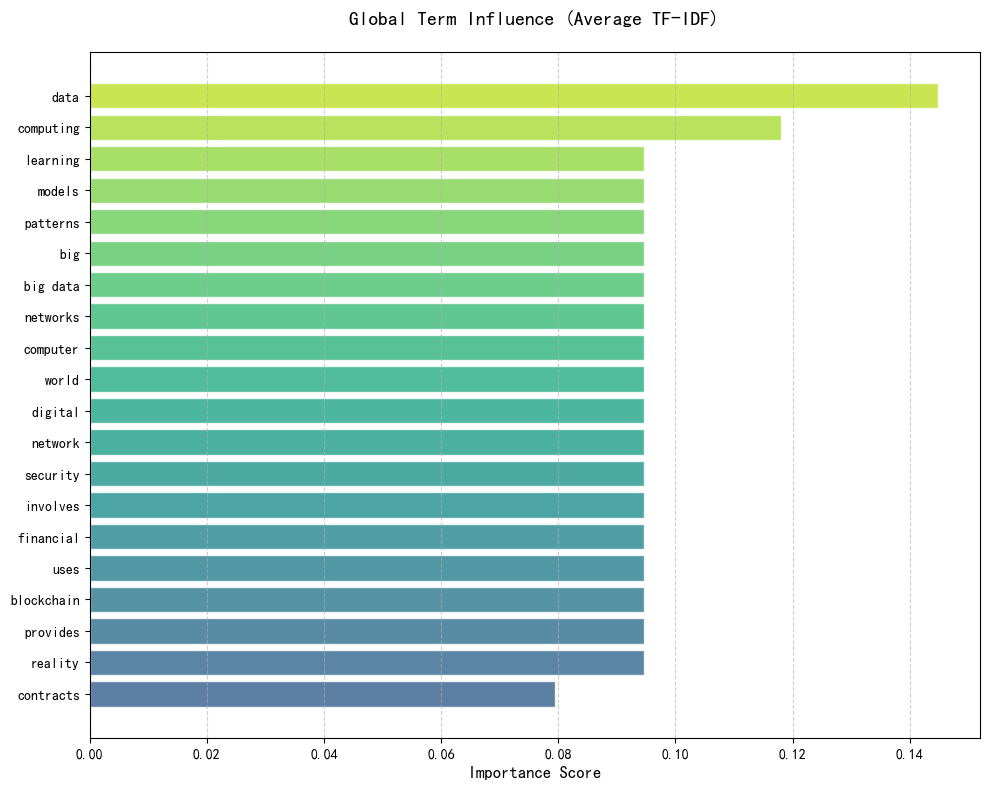

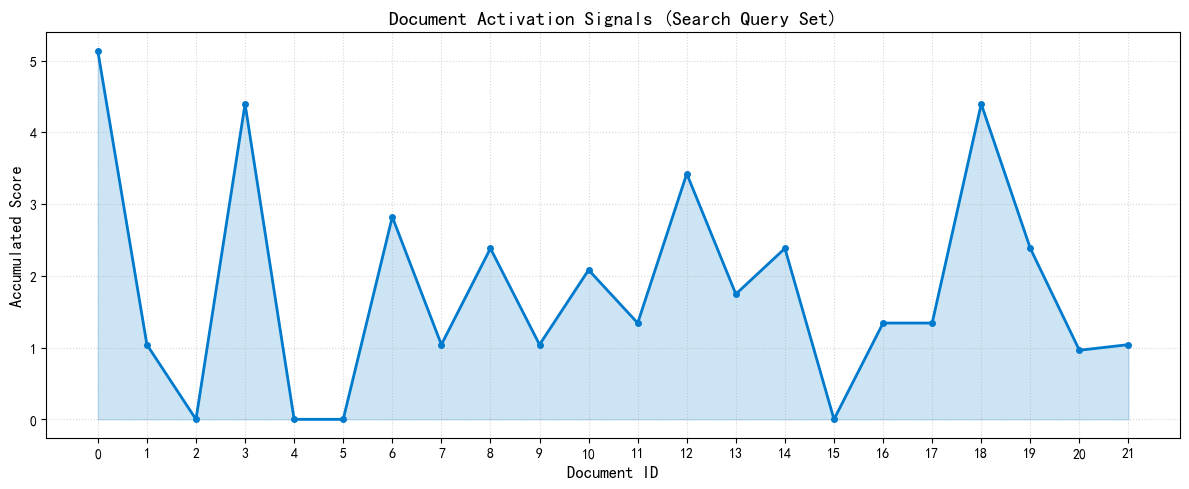

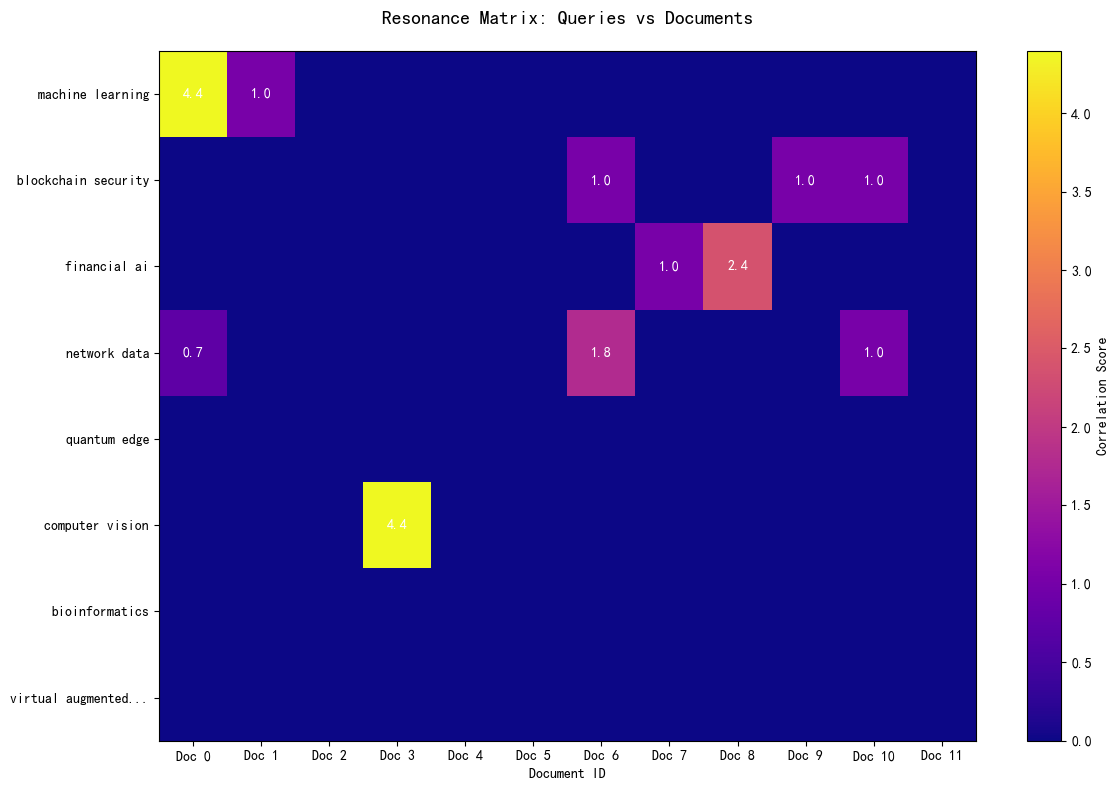

In [23]:
# 进阶示例：文本处理系统（TF-IDF, N-grams, Inverted Index）
import re
import math
import matplotlib.pyplot as plt
import numpy as np
from typing import List, Tuple, Dict, Set
from collections import Counter

# 设置现代化绘图风格
plt.style.use('seaborn-v0_8-muted')
plt.rcParams['font.sans-serif'] = ['SimHei']  # 适配中文显示（如有）
plt.rcParams['axes.unicode_minus'] = False

class TextSearchEngine:
    def __init__(self, stopwords: List[str] = None):
        if stopwords is None:
            # 扩展停用词表
            self.stopwords = {
                'the', 'and', 'is', 'in', 'to', 'of', 'a', 'for', 'it', 'on', 'with', 'at', 'by', 'an', 'be', 'this', 'that', 
                'which', 'who', 'whom', 'whose', 'this', 'that', 'these', 'those', 'am', 'are', 'was', 'were', 'been', 'being', 
                'have', 'has', 'had', 'do', 'does', 'did', 'but', 'if', 'or', 'as', 'until', 'while', 'while', 'of', 'at', 
                'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 
                'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 
                'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 
                'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', 'too', 'very', 's', 't', 
                'can', 'will', 'just', 'don', 'should', 'now', 'are', 'it'
            }
        else:
            self.stopwords = set(stopwords)
        
        self.inverted_index: Dict[str, Dict[int, int]] = {}
        self.documents: Dict[int, Dict] = {}
        self.doc_count = 0

    def clean_text(self, text: str) -> str:
        """深度清理：移除 HTML 标签、URL、特殊字符、转换为小写"""
        text = re.sub(r'<[^>]+>', ' ', text)
        text = re.sub(r'https?://[^\s<>"]+|www\.[^\s<>"]+', ' ', text)
        text = re.sub(r'[^\w\s]', ' ', text)
        text = re.sub(r'\s+', ' ', text)
        return text.lower().strip()

    def extract_emails(self, text: str) -> List[str]:
        """从原始文本中提取所有邮箱地址"""
        email_pattern = r'\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Z|a-z]{2,}\b'
        return re.findall(email_pattern, text)

    def tokenize(self, text: str) -> List[str]:
        """分词并过滤停用词"""
        cleaned = self.clean_text(text)
        words = cleaned.split()
        return [w for w in words if w not in self.stopwords and len(w) > 1]

    def get_ngrams(self, tokens: List[str], n: int) -> List[str]:
        """生成 n-grams 序列"""
        return [' '.join(tokens[i:i+n]) for i in range(len(tokens) - n + 1)] if len(tokens) >= n else []

    def add_document(self, text: str) -> int:
        """将文档添加到索引系统"""
        doc_id = self.doc_count
        tokens = self.tokenize(text)
        all_terms = tokens + self.get_ngrams(tokens, 2)
        term_freqs = Counter(all_terms)
        
        self.documents[doc_id] = {
            'raw': text,
            'term_counts': term_freqs,
            'emails': self.extract_emails(text),
            'token_count': len(tokens)
        }
        
        if all_terms:
            for term, freq in term_freqs.items():
                if term not in self.inverted_index:
                    self.inverted_index[term] = {}
                self.inverted_index[term][doc_id] = freq
            
        self.doc_count += 1
        return doc_id

    def calculate_tfidf(self, term: str, doc_id: int) -> float:
        """计算 TF-IDF 得分"""
        if term not in self.inverted_index or doc_id not in self.inverted_index[term]:
            return 0.0
        tf = 1 + math.log10(self.inverted_index[term][doc_id])
        docs_with_term = len(self.inverted_index[term])
        idf = math.log10(self.doc_count / docs_with_term) if self.doc_count > 0 else 0
        return tf * idf

    def get_all_global_weights(self, top_n: int = 20) -> List[Tuple[str, float]]:
        """获取全语料库中平均 TF-IDF 最高的关键词（全局影响力）"""
        global_scores = Counter()
        for term in self.inverted_index:
            total_score = sum(self.calculate_tfidf(term, d_id) for d_id in self.inverted_index[term])
            global_scores[term] = total_score / self.doc_count
        return global_scores.most_common(top_n)

    def search(self, query: str) -> List[Dict]:
        """综合搜索：TF-IDF 得分 + Bigram 加权"""
        query_tokens = self.tokenize(query)
        if not query_tokens:
            return []
        search_terms = query_tokens + self.get_ngrams(query_tokens, 2)
        
        scores = Counter()
        for term in search_terms:
            if term in self.inverted_index:
                weight = 1.5 if ' ' in term else 1.0
                for doc_id in self.inverted_index[term]:
                    scores[doc_id] += self.calculate_tfidf(term, doc_id) * weight
        
        results = []
        for doc_id, score in sorted(scores.items(), key=lambda x: x[1], reverse=True):
            results.append({
                'doc_id': doc_id,
                'score': round(score, 4),
                'text': self.documents[doc_id]['raw']
            })
        return results

def plot_global_influence(engine: TextSearchEngine):
    """图1：全局影响力渐变条形图"""
    data = engine.get_all_global_weights(20)
    terms, scores = zip(*data[::-1])  # 倒序以便条形图从上往下排
    
    plt.figure(figsize=(10, 8))
    colors = plt.cm.viridis(np.linspace(0.3, 0.9, len(terms)))
    bars = plt.barh(terms, scores, color=colors, edgecolor='white', alpha=0.8)
    
    plt.title('Global Term Influence (Average TF-IDF)', fontsize=14, pad=20)
    plt.xlabel('Importance Score', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

def plot_activation_signal(engine: TextSearchEngine, queries: List[str]):
    """图2：激活信号曲线（文档活跃能量）"""
    doc_ids = range(engine.doc_count)
    total_energies = np.zeros(engine.doc_count)
    
    for q in queries:
        results = engine.search(q)
        for res in results:
            total_energies[res['doc_id']] += res['score']
            
    plt.figure(figsize=(12, 5))
    plt.plot(doc_ids, total_energies, color='#007acc', linewidth=2, marker='o', markersize=4, label='Signal Strength')
    plt.fill_between(doc_ids, total_energies, color='#007acc', alpha=0.2)
    
    plt.title('Document Activation Signals (Search Query Set)', fontsize=14)
    plt.xlabel('Document ID', fontsize=12)
    plt.ylabel('Accumulated Score', fontsize=12)
    plt.xticks(doc_ids)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

def plot_resonance_heatmap(engine: TextSearchEngine, queries: List[str], doc_indices: List[int]):
    """图3：共鸣热力图 (Query-Document Correlation)"""
    matrix = np.zeros((len(queries), len(doc_indices)))
    
    for i, q in enumerate(queries):
        res_dict = {r['doc_id']: r['score'] for r in engine.search(q)}
        for j, d_id in enumerate(doc_indices):
            matrix[i, j] = res_dict.get(d_id, 0.0)
            
    plt.figure(figsize=(12, 8))
    im = plt.imshow(matrix, cmap='plasma', aspect='auto')
    
    # 添加标注
    for i in range(len(queries)):
        for j in range(len(doc_indices)):
            if matrix[i, j] > 0.5:
                plt.text(j, i, f'{matrix[i,j]:.1f}', ha='center', va='center', color='white', fontweight='bold')

    plt.colorbar(im, label='Correlation Score')
    plt.title('Resonance Matrix: Queries vs Documents', fontsize=14, pad=20)
    plt.yticks(range(len(queries)), [q if len(q) < 20 else q[:17]+'...' for q in queries])
    plt.xticks(range(len(doc_indices)), [f'Doc {d}' for d in doc_indices])
    plt.xlabel('Document ID')
    plt.tight_layout()
    plt.show()

# 使用示例
if __name__ == "__main__":
    engine = TextSearchEngine()
    
    corpus = [
        "Machine learning models identify complex patterns in big data.",
        "Deep learning and neural networks power modern artificial intelligence.",
        "Natural language processing helps computers understand human speech.",
        "Computer vision enables machines to interpret the visual world.",
        "Cybersecurity measures protect systems and networks from digital attacks.",
        "Cryptography is the practice of securing communication from third parties.",
        "Network security involves protecting data integrity and confidentiality.",
        "Fintech innovation aims to compete with traditional financial methods.",
        "Algorithmic trading uses AI models to execute financial trades rapidly.",
        "Blockchain technology provides a decentralized ledger for secure transactions.",
        "Smart contracts are self-executing contracts on a blockchain network.",
        "Cloud computing provides on-demand availability of system resources.",
        "Edge computing brings data storage closer to the device location.",
        "Quantum computing uses quantum phenomena to perform computations.",
        "Bioinformatics applies computer science to molecular biology.",
        "Genomics focuses on the structure and function of genomes.",
        "Robotics involves the design and operation of intelligent robots.",
        "Internet of Things (IoT) connects physical objects to the web.",
        "Augmented reality overlays digital information onto the real world.",
        "Virtual reality creates simulated environments for immersive experiences.",
        "Big data analytics examines large data sets for hidden patterns.",
        "Security protocols are essential for maintaining online privacy."
    ]
    
    for text in corpus:
        engine.add_document(text)
    
    test_queries = [
        "machine learning", "blockchain security", "financial ai", 
        "network data", "quantum edge", "computer vision", 
        "bioinformatics", "virtual augmented reality", "iot robotics", "cloud storage"
    ]
    
    # 依次展示三个独立图表
    print("生成可视化图表中...")
    plot_global_influence(engine)
    plot_activation_signal(engine, test_queries)
    plot_resonance_heatmap(engine, test_queries[:8], list(range(12)))



**提示词：**
第一段：
```text
请基于我现在的文本处理函数（clean_text, extract_emails），实现一个更专业的关键词提取和索引系统。要求：

引入 TF-IDF 算法来衡量关键词的重要性，而不仅仅是计算频率。
支持 Unigram（单词）和 Bigram（双词短语）提取。
构建一个倒排索引（Inverted Index），以便在不遍历原文的情况下快速检索文档。
实现一个 search 函数，结合 TF-IDF 匹配得分和关键词命中加权进行综合打分。
```
第二段：
```text
现在的关键词提取结果有些单一，请进一步优化：

扩充停用词表（Stopwords），过滤掉如 'will', 'can', 'that' 等无实际意义的高频词。
增加对 URL 和 HTML 标签的深度清理。
准备一份包含 20 条以上、涵盖不同技术领域（如机器学习、网络安全、金融分析）的模拟语料库，并设计 10 个针对性的搜索查询语句。
确保算法在面对极短文本或无匹配关键词时不会报错，并返回 0 分。
```
第三段：
```text
我已经有了检索结果的分数，请使用 matplotlib 和 numpy 为我设计一套现代化的可视化分析方案：

不要将所有图画在一起，每张图独立展示以便于观察。
图1：全局影响力。使用渐变色水平条形图展示语料库中权重最高的前 20 个关键词。
图2：激活信号曲线。将文档 ID 作为 X 轴，展示在当前查询集下各文档的“活跃能量”折线图，并添加半透明填充增强对比。
图3：共鸣热力图。绘制 Query 与 Document 的相关性矩阵，使用 plasma 或 magma 配色，并在高分格子中自动标注数值。
确保绘图风格简洁、现代化（如使用 seaborn-v0_8 样式）。
```